# CAISO Demand Forecasting with MLP

Standard feed-forward neural network on the same lag features as the KAN baseline.

- **Input (14 features):** weather + economic + calendar + lag-1h / lag-24h / lag-168h
- **Architecture:** `[14 → 64 → 32 → 1]` with ReLU activations + dropout
- **Training:** Adam with learning-rate scheduling

In [22]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

DATA = '../../data/processed/combined_hourly.csv'

FEATURES = ['temperature_c', 'precipitation_mm', 'solar_radiation_wm2',
            'windspeed_ms', 'humidity_pct', 'gas_price_mmbtu',
            'is_holiday', 'is_weekend', 'hour_of_day', 'day_of_week', 'month']

SCALE_COLS = ['load_mw', 'temperature_c', 'precipitation_mm', 'solar_radiation_wm2',
              'windspeed_ms', 'humidity_pct', 'gas_price_mmbtu']

TARGET = 'load_mw'

torch.manual_seed(1)

### 1. Load & lag features

In [23]:
df = pd.read_csv(DATA, parse_dates=['datetime'], index_col='datetime')

df['load_lag1']   = df[TARGET].shift(1)
df['load_lag24']  = df[TARGET].shift(24)
df['load_lag168'] = df[TARGET].shift(168)
df = df.dropna()

LAG_FEATURES = FEATURES + ['load_lag1', 'load_lag24', 'load_lag168']
print(f'{len(df):,} rows | {len(LAG_FEATURES)} input features')

40,422 rows | 14 input features


### 2. Split then standardise (train stats only)

In [24]:
split = int(len(df) * 0.8)
train_raw, test_raw = df.iloc[:split].copy(), df.iloc[split:].copy()
print(f'Train: {len(train_raw):,}  {train_raw.index[0].date()} to {train_raw.index[-1].date()}')
print(f'Test:  {len(test_raw):,}   {test_raw.index[0].date()} to {test_raw.index[-1].date()}')

LAG_SCALE = SCALE_COLS + ['load_lag1', 'load_lag24', 'load_lag168']
scaler = {col: {'mean': train_raw[col].mean(), 'std': train_raw[col].std()}
          for col in LAG_SCALE}

train, test = train_raw.copy(), test_raw.copy()
for col, s in scaler.items():
    train[col] = (train[col] - s['mean']) / s['std']
    test[col]  = (test[col]  - s['mean']) / s['std']

load_mean = scaler['load_mw']['mean']
load_std  = scaler['load_mw']['std']
print(f'load_mw  mean={load_mean:.1f} MW  std={load_std:.1f} MW  (train only)')

def to_tensor(frame, cols):
    return torch.tensor(frame[cols].values, dtype=torch.float32)

X_train = to_tensor(train, LAG_FEATURES)
y_train = to_tensor(train, [TARGET])
X_test  = to_tensor(test,  LAG_FEATURES)
y_test  = to_tensor(test,  [TARGET])

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=2048, shuffle=True)
print('X_train shape:', X_train.shape)

Train: 32,337  2019-01-08 to 2023-11-30
Test:  8,085   2023-11-30 to 2024-12-31
load_mw  mean=24029.3 MW  std=3172.8 MW  (train only)
X_train shape: torch.Size([32337, 14])


### 3. Define MLP

In [25]:
class MLP(nn.Module):
    def __init__(self, in_features, hidden=(64, 32), dropout=0.1):
        super().__init__()
        layers = []
        prev = in_features
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

model = MLP(in_features=len(LAG_FEATURES))
print(model)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

MLP(
  (net): Sequential(
    (0): Linear(in_features=14, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)
Parameters: 3,073


### 4. Train

In [26]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

EPOCHS = 80
train_losses, test_losses = [], []

for epoch in range(1, EPOCHS + 1):
    model.train()
    batch_losses = []
    for xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        test_loss = criterion(model(X_test), y_test).item()

    train_loss = np.mean(batch_losses)
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    scheduler.step(test_loss)

    if epoch % 10 == 0:
        print(f'Epoch {epoch:3d}  train={train_loss:.4f}  test={test_loss:.4f}')

Epoch  10  train=0.0929  test=0.0641
Epoch  20  train=0.0621  test=0.0468
Epoch  30  train=0.0514  test=0.0415
Epoch  40  train=0.0465  test=0.0411
Epoch  50  train=0.0446  test=0.0399
Epoch  60  train=0.0427  test=0.0392
Epoch  70  train=0.0418  test=0.0392
Epoch  80  train=0.0414  test=0.0389


### 5. Loss curve

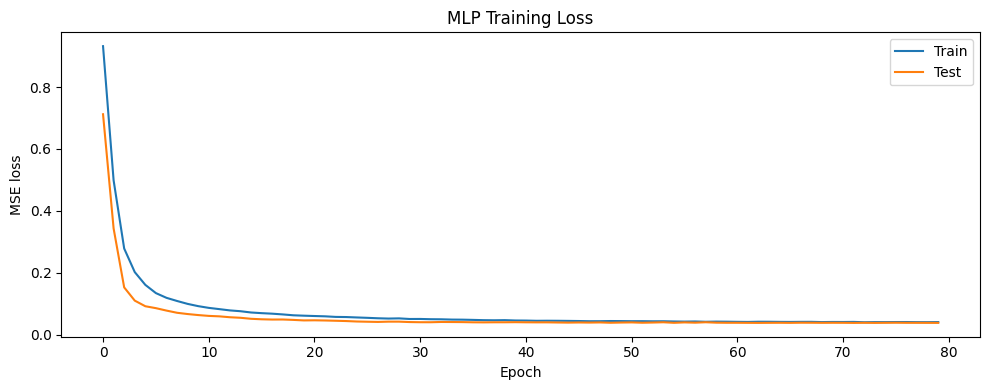

In [27]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_losses, label='Train')
ax.plot(test_losses,  label='Test')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE loss')
ax.set_title('MLP Training Loss')
ax.legend()
plt.tight_layout()
plt.show()

### 6. Evaluate on test set

In [28]:
model.eval()
with torch.no_grad():
    pred = model(X_test).squeeze().numpy()

y_true = y_test.squeeze().numpy()

rmse = np.sqrt(mean_squared_error(y_true, pred))
mae  = mean_absolute_error(y_true, pred)
r2   = r2_score(y_true, pred)

print(f'MLP (lag features, train-only scaler)')
print(f'  RMSE  {rmse:.4f}  ({rmse * load_std:.0f} MW)')
print(f'  MAE   {mae:.4f}  ({mae  * load_std:.0f} MW)')
print(f'  R2    {r2:.4f}')

MLP (lag features, train-only scaler)
  RMSE  0.1972  (626 MW)
  MAE   0.1489  (472 MW)
  R2    0.9632


### 7. Predictions vs actuals (first 2 weeks of test)

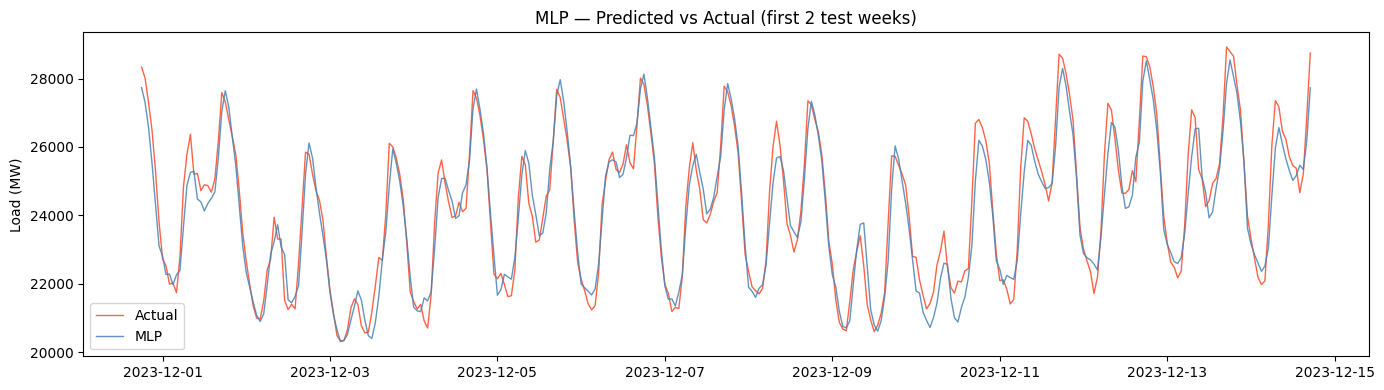

In [29]:
n   = 24 * 14
idx = test.index[:n]
actual = y_true[:n] * load_std + load_mean

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(idx, actual,                          color='tomato',    linewidth=1,        label='Actual')
ax.plot(idx, pred[:n] * load_std + load_mean, color='steelblue', linewidth=1, alpha=0.85, label='MLP')
ax.set_ylabel('Load (MW)')
ax.set_title('MLP — Predicted vs Actual (first 2 test weeks)')
ax.legend()
plt.tight_layout()
plt.show()